### Modelo de forecasting de demanda SKU 455151

In [2]:
import sys
print(sys.executable)

c:\Program Files\Python314\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

SKU = '455151'
NOMBRE_SKU = 'MS 5-tier Storage Rack'
PAIS = 'Colombia'
DATA_PATH = '../DATA/raw/ventashistoricas_455151.csv'

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


#### 1. Carga de Datos y Filtrado

In [4]:
# Cargar datos
df = pd.read_csv(DATA_PATH)
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

# Filtrar Colombia
df = df[df['Country'] == PAIS]
df = df[df['Quantity'] > 0].dropna(subset=['Quantity'])

print(f"Transacciones de {PAIS}: {len(df):,}")
print(f"Clubes: {df['Cost_Center'].nunique()}")

# Agregar por fecha (demanda diaria)
demanda_diaria = df.groupby('Transaction_Date')['Quantity'].sum().reset_index()
demanda_diaria.columns = ['fecha', 'demanda']
demanda_diaria = demanda_diaria.sort_values('fecha').reset_index(drop=True)

print(f"\nRango de fechas: {demanda_diaria['fecha'].min().date()} a {demanda_diaria['fecha'].max().date()}")
print(f"Total días: {len(demanda_diaria)}")
print(f"\nEstadísticas de demanda diaria Colombia:")
print(demanda_diaria['demanda'].describe())


Transacciones de Colombia: 2,096
Clubes: 10

Rango de fechas: 2025-05-23 a 2026-06-18
Total días: 387

Estadísticas de demanda diaria Colombia:
count    387.000000
mean      13.638243
std        8.556329
min        1.000000
25%        7.000000
50%       12.000000
75%       18.000000
max       54.000000
Name: demanda, dtype: float64


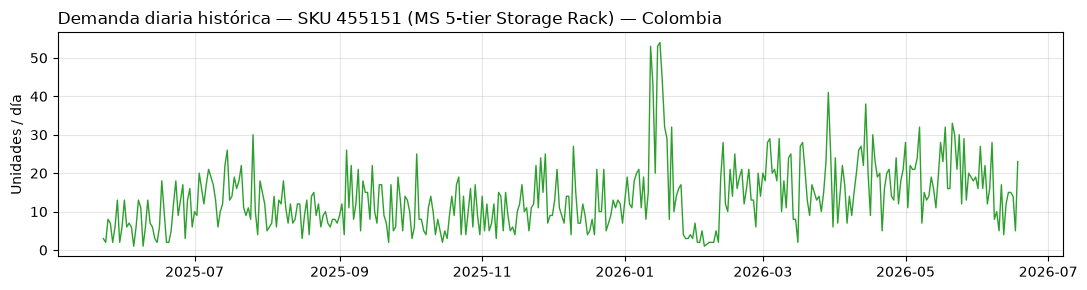

Demanda promedio: 13.6 u/día
Coeficiente de variación (CV): 0.63


In [5]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(demanda_diaria['fecha'], demanda_diaria['demanda'], 
        linewidth=1.0, color='#2ca02c')
ax.set_title(f"Demanda diaria histórica — SKU {SKU} ({NOMBRE_SKU}) — {PAIS}", loc='left')
ax.set_ylabel('Unidades / día')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

cv = demanda_diaria['demanda'].std() / demanda_diaria['demanda'].mean()
print(f"Demanda promedio: {demanda_diaria['demanda'].mean():.1f} u/día")
print(f"Coeficiente de variación (CV): {cv:.2f}")


#### 2. Ingeniería de Features

In [6]:
df_model = demanda_diaria.copy()

# Variables de calendario
df_model['dia_semana'] = df_model['fecha'].dt.dayofweek
df_model['mes'] = df_model['fecha'].dt.month
df_model['semana_anio'] = df_model['fecha'].dt.isocalendar().week.astype(int)
df_model['es_finde'] = (df_model['dia_semana'] >= 5).astype(int)

# Lags
df_model['lag_7'] = df_model['demanda'].shift(7)
df_model['lag_14'] = df_model['demanda'].shift(14)
df_model['lag_30'] = df_model['demanda'].shift(30)

# Promedios móviles
df_model['media_movil_7'] = df_model['demanda'].shift(1).rolling(7).mean()
df_model['media_movil_30'] = df_model['demanda'].shift(1).rolling(30).mean()

df_model = df_model.dropna().reset_index(drop=True)

print("Shape después de features:", df_model.shape)
print("Features:", df_model.columns.tolist())
df_model.head()


Shape después de features: (357, 11)
Features: ['fecha', 'demanda', 'dia_semana', 'mes', 'semana_anio', 'es_finde', 'lag_7', 'lag_14', 'lag_30', 'media_movil_7', 'media_movil_30']


,fecha,demanda,dia_semana,mes,semana_anio,es_finde,lag_7,lag_14,lag_30,media_movil_7,media_movil_30
0,2025-06-23,18.0,0,6,26,0,2.0,11.0,3.0,6.714286,6.500000
1,2025-06-24,9.0,1,6,26,0,6.0,1.0,2.0,9.000000,7.000000
2,2025-06-25,13.0,2,6,26,0,18.0,6.0,8.0,9.428571,7.233333
3,2025-06-26,17.0,3,6,26,0,2.0,13.0,7.0,8.714286,7.400000
4,2025-06-27,3.0,4,6,26,0,2.0,7.0,2.0,10.857143,7.733333


#### 3. División de Datos (Train / Test Split)

In [7]:
FEATURES = ['dia_semana', 'mes', 'semana_anio', 'es_finde',
            'lag_7', 'lag_14', 'lag_30', 'media_movil_7', 'media_movil_30']
TARGET = 'demanda'

X = df_model[FEATURES]
y = df_model[TARGET]

split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

fecha_corte = df_model['fecha'].iloc[split_idx]
print(f"Fecha de corte train/test: {fecha_corte.date()}")
print(f"Train: {len(X_train)} días ({df_model['fecha'].iloc[0].date()} a {df_model['fecha'].iloc[split_idx-1].date()})")
print(f"Test:  {len(X_test)} días ({fecha_corte.date()} a {df_model['fecha'].iloc[-1].date()})")


Fecha de corte train/test: 2026-04-08
Train: 285 días (2025-06-23 a 2026-04-07)
Test:  72 días (2026-04-08 a 2026-06-18)


In [8]:
from sklearn.model_selection import TimeSeriesSplit

def evaluar_modelo(y_true, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{nombre_modelo}")
    print(f"  MAE:  {mae:.2f} unidades")
    print(f"  RMSE: {rmse:.2f} unidades")
    print(f"  MAPE: {mape:.2f}%")
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

tscv = TimeSeriesSplit(n_splits=5)
print("TimeSeriesSplit configurado con 5 folds")


TimeSeriesSplit configurado con 5 folds


#### 4. Validación Cruzada Temporal (TimeSeriesSplit)

4.1 Modelo Baseline: Promedio Móvil de 7 días

In [9]:
y_pred_base = X_test['media_movil_7']
metricas_base = evaluar_modelo(y_test, y_pred_base, "Modelo Base (Promedio Móvil 7 días)")



Modelo Base (Promedio Móvil 7 días)
  MAE:  6.24 unidades
  RMSE: 7.60 unidades
  MAPE: 46.91%


4.2 Modelo 2: Random Forest Regressor

In [10]:
mae_cv_rf = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_cv_train, y_cv_train)
    y_cv_pred = rf.predict(X_cv_val)
    mae_fold = mean_absolute_error(y_cv_val, y_cv_pred)
    mae_cv_rf.append(mae_fold)
    print(f"  Fold {fold+1} MAE: {mae_fold:.2f}")

print(f"\nMAE promedio CV: {np.mean(mae_cv_rf):.2f} (+/- {np.std(mae_cv_rf):.2f})")

rf_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)
metricas_rf = evaluar_modelo(y_test, y_pred_rf, "Random Forest")

  Fold 1 MAE: 4.88
  Fold 2 MAE: 4.67
  Fold 3 MAE: 4.65
  Fold 4 MAE: 11.00
  Fold 5 MAE: 8.54

MAE promedio CV: 6.75 (+/- 2.59)

Random Forest
  MAE:  7.63 unidades
  RMSE: 9.19 unidades
  MAPE: 43.03%


4.3 Modelo 3: XGBoost Regressor

In [11]:
mae_cv_xgb = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
    xgb.fit(X_cv_train, y_cv_train)
    y_cv_pred = xgb.predict(X_cv_val)
    mae_fold = mean_absolute_error(y_cv_val, y_cv_pred)
    mae_cv_xgb.append(mae_fold)
    print(f"  Fold {fold+1} MAE: {mae_fold:.2f}")

print(f"\nMAE promedio CV: {np.mean(mae_cv_xgb):.2f} (+/- {np.std(mae_cv_xgb):.2f})")

xgb_final = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_final.fit(X_train, y_train)
y_pred_xgb = xgb_final.predict(X_test)
metricas_xgb = evaluar_modelo(y_test, y_pred_xgb, "XGBoost")


  Fold 1 MAE: 6.85
  Fold 2 MAE: 5.34
  Fold 3 MAE: 4.79
  Fold 4 MAE: 11.01
  Fold 5 MAE: 9.74

MAE promedio CV: 7.54 (+/- 2.44)

XGBoost
  MAE:  9.00 unidades
  RMSE: 10.62 unidades
  MAPE: 49.28%


#### 5. Comparacion de modelos


=== RESUMEN DE MÉTRICAS ===
Modelo                                   MAE     RMSE     MAPE
--------------------------------------------------------------
Base (Promedio Móvil 7 días)            6.24     7.60   46.91%
Random Forest (100 árboles)             7.63     9.19   43.03%
XGBoost (100 est., lr=0.1)              9.00    10.62   49.28%


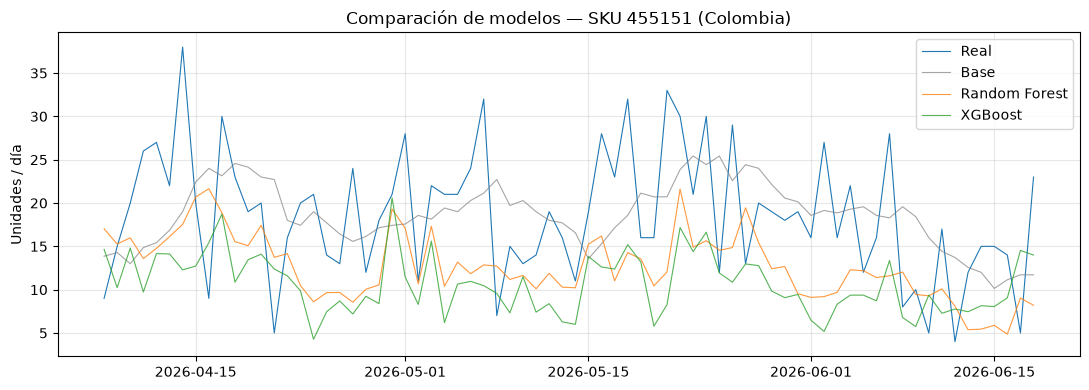

In [12]:
print("\n=== RESUMEN DE MÉTRICAS ===")
print(f"{'Modelo':<35} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 62)
print(f"{'Base (Promedio Móvil 7 días)':<35} {metricas_base['mae']:>8.2f} {metricas_base['rmse']:>8.2f} {metricas_base['mape']:>7.2f}%")
print(f"{'Random Forest (100 árboles)':<35} {metricas_rf['mae']:>8.2f} {metricas_rf['rmse']:>8.2f} {metricas_rf['mape']:>7.2f}%")
print(f"{'XGBoost (100 est., lr=0.1)':<35} {metricas_xgb['mae']:>8.2f} {metricas_xgb['rmse']:>8.2f} {metricas_xgb['mape']:>7.2f}%")

fig, ax = plt.subplots(figsize=(11, 4))
fechas_test = df_model['fecha'].iloc[split_idx:]
ax.plot(fechas_test, y_test.values, label='Real', linewidth=0.8, color='#1f77b4')
ax.plot(fechas_test, y_pred_base.values, label='Base', linewidth=0.8, color='gray', alpha=0.7)
ax.plot(fechas_test, y_pred_rf, label='Random Forest', linewidth=0.8, color='#ff7f0e', alpha=0.8)
ax.plot(fechas_test, y_pred_xgb, label='XGBoost', linewidth=0.8, color='#2ca02c', alpha=0.8)
ax.set_title(f'Comparación de modelos — SKU {SKU} ({PAIS})')
ax.set_ylabel('Unidades / día')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Registro en ML Flow

In [13]:
# Configurar MLflow — cambiar IP cuando el servidor EC2 esté disponible

mlflow.set_tracking_uri("http://44.200.196.170:5000/")
mlflow.set_experiment(f"Forecasting_SKU_{SKU}")

# Modelo base
with mlflow.start_run(run_name="modelo_base_promedio_movil"):
    mlflow.log_param("modelo", "promedio_movil")
    mlflow.log_param("ventana", 7)
    mlflow.log_param("sku", SKU)
    mlflow.log_param("pais", PAIS)
    mlflow.log_metric("mae", metricas_base['mae'])
    mlflow.log_metric("rmse", metricas_base['rmse'])
    mlflow.log_metric("mape", metricas_base['mape'])
    print("✓ Modelo base registrado")

# Random Forest
with mlflow.start_run(run_name="random_forest"):
    mlflow.log_param("modelo", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("sku", SKU)
    mlflow.log_param("pais", PAIS)
    mlflow.log_param("mae_cv_promedio", round(np.mean(mae_cv_rf), 2))
    mlflow.log_metric("mae", metricas_rf['mae'])
    mlflow.log_metric("rmse", metricas_rf['rmse'])
    mlflow.log_metric("mape", metricas_rf['mape'])
    print("✓ Random Forest registrado")

# XGBoost
with mlflow.start_run(run_name="xgboost"):
    mlflow.log_param("modelo", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("sku", SKU)
    mlflow.log_param("pais", PAIS)
    mlflow.log_param("mae_cv_promedio", round(np.mean(mae_cv_xgb), 2))
    mlflow.log_metric("mae", metricas_xgb['mae'])
    mlflow.log_metric("rmse", metricas_xgb['rmse'])
    mlflow.log_metric("mape", metricas_xgb['mape'])
    print("✓ XGBoost registrado")

print("\n¡Experimentos registrados en MLflow!")


✓ Modelo base registrado
🏃 View run modelo_base_promedio_movil at: http://44.200.196.170:5000/#/experiments/107721955732802975/runs/b0da34fef99d4a919ce6b8932dca1e5f
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/107721955732802975
✓ Random Forest registrado
🏃 View run random_forest at: http://44.200.196.170:5000/#/experiments/107721955732802975/runs/6a58d06ef5024a48ad31df7e0bd38fd8
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/107721955732802975
✓ XGBoost registrado
🏃 View run xgboost at: http://44.200.196.170:5000/#/experiments/107721955732802975/runs/5bfc0c42e8634d12a2157af68fec9bf4
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/107721955732802975

¡Experimentos registrados en MLflow!


#### Guardar el mejor modelo

In [14]:
# Guardar modelo
os.makedirs('../models', exist_ok=True)
joblib.dump(xgb_final, '../models/modelo_455151_colombia.pkl')
print(f"Mejor modelo: XGBoost")
print(f"  MAPE: {metricas_xgb['mape']:.2f}%")
print(f"  MAE:  {metricas_xgb['mae']:.2f} unidades")
print("Modelo guardado en: ../models/modelo_455151_colombia.pkl")


Mejor modelo: XGBoost
  MAPE: 49.28%
  MAE:  9.00 unidades
Modelo guardado en: ../models/modelo_455151_colombia.pkl


In [15]:
# Forecast próximos 30 días
ultima_fecha = demanda_diaria['fecha'].max()
fechas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(days=1), periods=30)

predicciones = []
historial = demanda_diaria['demanda'].values.tolist()
hist_temp = historial.copy()

for fecha in fechas_futuras:
    features = {
        'dia_semana': fecha.dayofweek,
        'mes': fecha.month,
        'semana_anio': fecha.isocalendar()[1],
        'es_finde': int(fecha.dayofweek >= 5),
        'lag_7': hist_temp[-7],
        'lag_14': hist_temp[-14],
        'lag_30': hist_temp[-30],
        'media_movil_7': np.mean(hist_temp[-7:]),
        'media_movil_30': np.mean(hist_temp[-30:]),
    }
    pred = xgb_final.predict(pd.DataFrame([features]))[0]
    predicciones.append(pred)
    hist_temp.append(pred)

forecast_df = pd.DataFrame({
    'fecha': fechas_futuras,
    'demanda_forecast': [round(p) for p in predicciones]
})

print("Forecast próximos 30 días:")
print(forecast_df.to_string(index=False))
print(f"\nDemanda total estimada (30 días): {forecast_df['demanda_forecast'].sum():,} unidades")
print(f"Demanda diaria promedio estimada: {forecast_df['demanda_forecast'].mean():.0f} unidades")


Forecast próximos 30 días:
     fecha  demanda_forecast
2026-06-19                12
2026-06-20                13
2026-06-21                17
2026-06-22                25
2026-06-23                23
2026-06-24                13
2026-06-25                12
2026-06-26                13
2026-06-27                14
2026-06-28                15
2026-06-29                14
2026-06-30                15
2026-07-01                16
2026-07-02                12
2026-07-03                14
2026-07-04                14
2026-07-05                12
2026-07-06                17
2026-07-07                18
2026-07-08                15
2026-07-09                14
2026-07-10                12
2026-07-11                14
2026-07-12                14
2026-07-13                11
2026-07-14                17
2026-07-15                15
2026-07-16                16
2026-07-17                15
2026-07-18                14

Demanda total estimada (30 días): 446 unidades
Demanda diaria promedio es